# Electricity Grid Database —Data Analysis

**Domain:** Indian Electricity Distribution Grid 

---

## 0 · Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
from db.connection import get_connection

import warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

# Plotting defaults
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]#blue, green, red, purple, yellow, cyan

In [2]:
def sql(query, params=None):
    conn = get_connection()
    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    return df

In [3]:
def sql_grid(query, params=None):
    return sql(f"SET search_path TO electricity_grid_management; {query}", params)

print("✓ Connected to electricity_grid database")

✓ Connected to electricity_grid database


---
## 1 · Exploratory Data Analysis (EDA) & Data Profiling


### 1.1 — Customer Distribution by Type

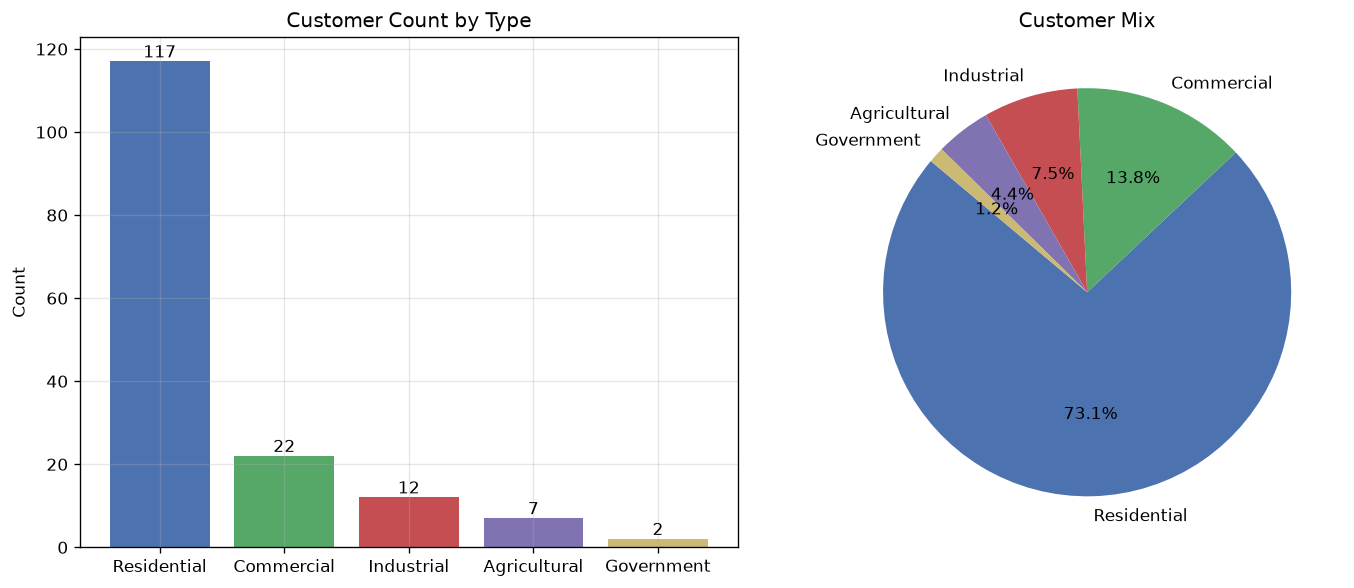

In [4]:
cust_type = sql_grid("""
    SELECT ct.Type_Name, COUNT(*) AS count
    FROM Customer c
    JOIN Customer_Type ct ON c.Customer_Type_ID = ct.Customer_Type_ID
    GROUP BY ct.Type_Name
    ORDER BY count DESC;
""")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(cust_type["type_name"], cust_type["count"], color=COLORS[:len(cust_type)])
axes[0].set_title("Customer Count by Type")
axes[0].set_ylabel("Count")
for i, v in enumerate(cust_type["count"]):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=10)

# Pie chart
axes[1].pie(cust_type["count"], labels=cust_type["type_name"],
            autopct="%1.1f%%", startangle=140, colors=COLORS[:len(cust_type)])
axes[1].set_title("Customer Mix")

plt.tight_layout()
plt.show()

### 1.2 — Customer Distribution by State

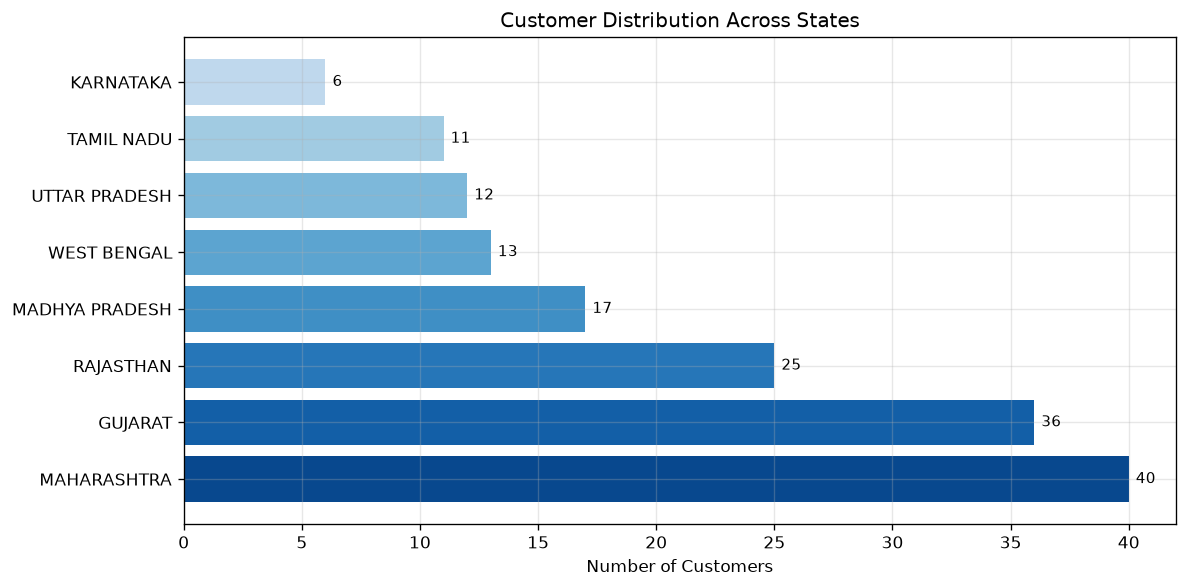

In [5]:
cust_state = sql_grid("""
    SELECT pc.State, COUNT(*) AS count
    FROM Customer c
    JOIN Pin_Code pc ON c.Pin_Code = pc.Pin_Code
    GROUP BY pc.State
    ORDER BY count DESC;
""")

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues([(i + 3) / (len(cust_state) + 3) for i in range(len(cust_state))])[::-1]
ax.barh(cust_state["state"], cust_state["count"], color=colors)
ax.set_xlabel("Number of Customers")
ax.set_title("Customer Distribution Across States")
for i, v in enumerate(cust_state["count"]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 1.3 — Bill Amount Distribution & Payment Status

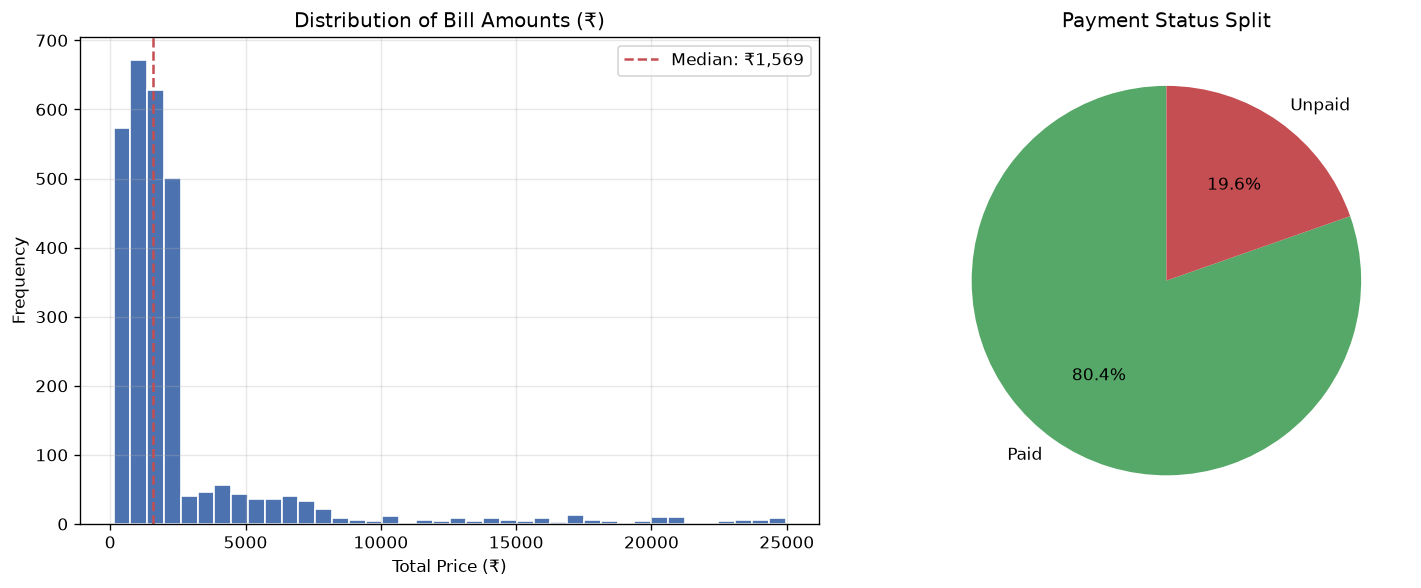

count     2888.00
mean      2633.31
std       3813.42
min        126.04
25%        890.87
50%       1568.68
75%       2296.16
max      24953.90
Name: total_price, dtype: float64


In [6]:
bills = sql_grid("""
    SELECT Total_Price, Payment_Status,
           DATE_PART('year', Billing_Date)::int AS year
    FROM Bill;
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(bills["total_price"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Bill Amounts (₹)")
axes[0].set_xlabel("Total Price (₹)")
axes[0].set_ylabel("Frequency")
median_val = bills["total_price"].median()
axes[0].axvline(median_val, color="#C44E52", linestyle="--", label=f"Median: ₹{median_val:,.0f}")
axes[0].legend()

# Payment status pie
status_counts = bills["payment_status"].value_counts()
axes[1].pie(status_counts, labels=status_counts.index,
            autopct="%1.1f%%", startangle=90,
            colors=["#55A868", "#C44E52"])
axes[1].set_title("Payment Status Split")

plt.tight_layout()
plt.show()

print(bills["total_price"].describe().round(2))

### 1.4 — Connection Status Breakdown

In [7]:
conn_status = sql_grid("""
    SELECT Connection_Status, COUNT(*) AS count
    FROM Customer
    GROUP BY Connection_Status;
""")

print(conn_status.to_string(index=False))
disconnected = conn_status.loc[conn_status["connection_status"] == "Disconnected", "count"].values[0]
total = conn_status["count"].sum()
print(f"\nDisconnection Rate: {disconnected / total * 100:.1f}%")

connection_status  count
     Disconnected     26
        Connected    134

Disconnection Rate: 16.2%


## 2 · Revenue Analysis

### 2.1 — Revenue by Customer Type (All Years)

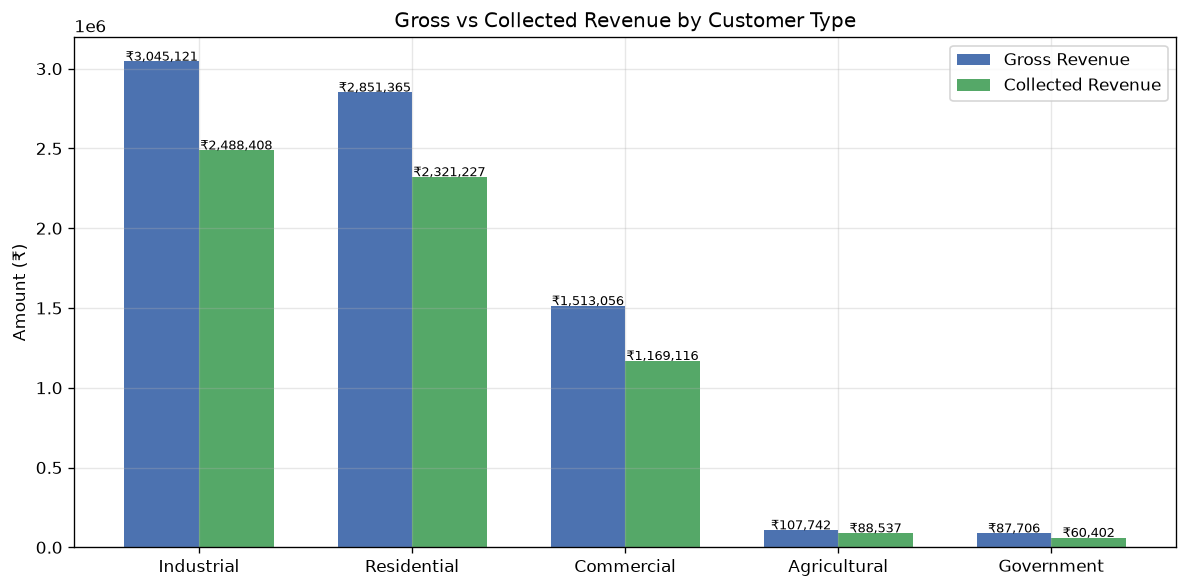

   type_name  gross_revenue  paid_revenue  collection_rate
  Industrial     3045121.32    2488407.64             81.7
 Residential     2851365.49    2321226.79             81.4
  Commercial     1513056.32    1169115.73             77.3
Agricultural      107742.23      88536.90             82.2
  Government       87705.63      60401.64             68.9


In [8]:
rev_by_type = sql_grid("""
    SELECT ct.Type_Name,
           SUM(CASE WHEN b.Payment_Status = 'Paid' THEN b.Total_Price ELSE 0 END) AS paid_revenue,
           SUM(b.Total_Price) AS gross_revenue
    FROM Bill b
    JOIN Electricity_Rate er ON er.Rate_ID = b.Rate_ID
    JOIN Customer_Type ct    ON ct.Customer_Type_ID = er.Customer_Type_ID
    GROUP BY ct.Type_Name
    ORDER BY paid_revenue DESC;
""")

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(rev_by_type))
w = 0.35
ax.bar([i - w/2 for i in x], rev_by_type["gross_revenue"], w, label="Gross Revenue", color="#4C72B0")
ax.bar([i + w/2 for i in x], rev_by_type["paid_revenue"], w, label="Collected Revenue", color="#55A868")
ax.set_xticks(list(x))
ax.set_xticklabels(rev_by_type["type_name"])
ax.set_ylabel("Amount (₹)")
ax.set_title("Gross vs Collected Revenue by Customer Type")
ax.legend()

for i, (g, p) in enumerate(zip(rev_by_type["gross_revenue"], rev_by_type["paid_revenue"])):
    ax.text(i - w/2, g + 5000, f"₹{g:,.0f}", ha="center", fontsize=8)
    ax.text(i + w/2, p + 5000, f"₹{p:,.0f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# Collection rate
rev_by_type["collection_rate"] = (rev_by_type["paid_revenue"] / rev_by_type["gross_revenue"] * 100).round(1)
print(rev_by_type[["type_name", "gross_revenue", "paid_revenue", "collection_rate"]].to_string(index=False))

### 2.2 — Yearly Revenue Trend by Customer Type

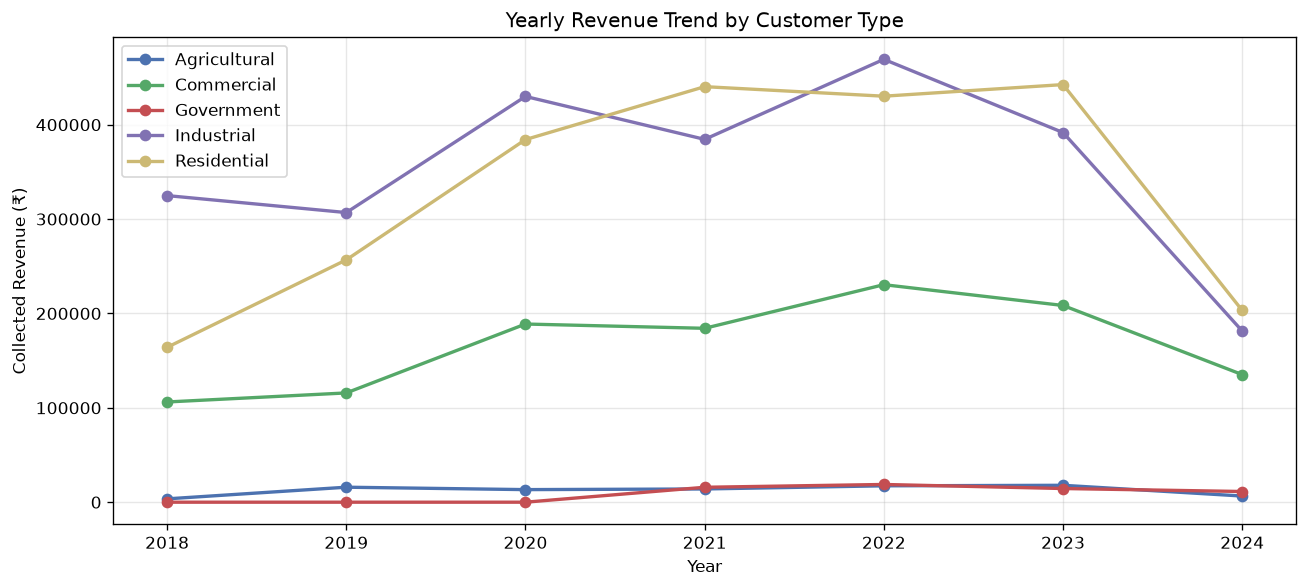

In [9]:
yearly_rev = sql_grid("""
    SELECT DATE_PART('year', b.Billing_Date)::int AS year,
           ct.Type_Name,
           SUM(CASE WHEN b.Payment_Status = 'Paid' THEN b.Total_Price ELSE 0 END) AS revenue
    FROM Bill b
    JOIN Electricity_Rate er ON er.Rate_ID = b.Rate_ID
    JOIN Customer_Type ct    ON ct.Customer_Type_ID = er.Customer_Type_ID
    GROUP BY year, ct.Type_Name
    ORDER BY year;
""")

pivot = yearly_rev.pivot(index="year", columns="type_name", values="revenue").fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
for i, col in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[col], marker="o", label=col, color=COLORS[i % len(COLORS)], linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Collected Revenue (₹)")
ax.set_title("Yearly Revenue Trend by Customer Type")
ax.legend(loc="upper left")
ax.set_xticks(pivot.index)
plt.tight_layout()
plt.show()

### 2.3 — Total Revenue YoY Growth Rate

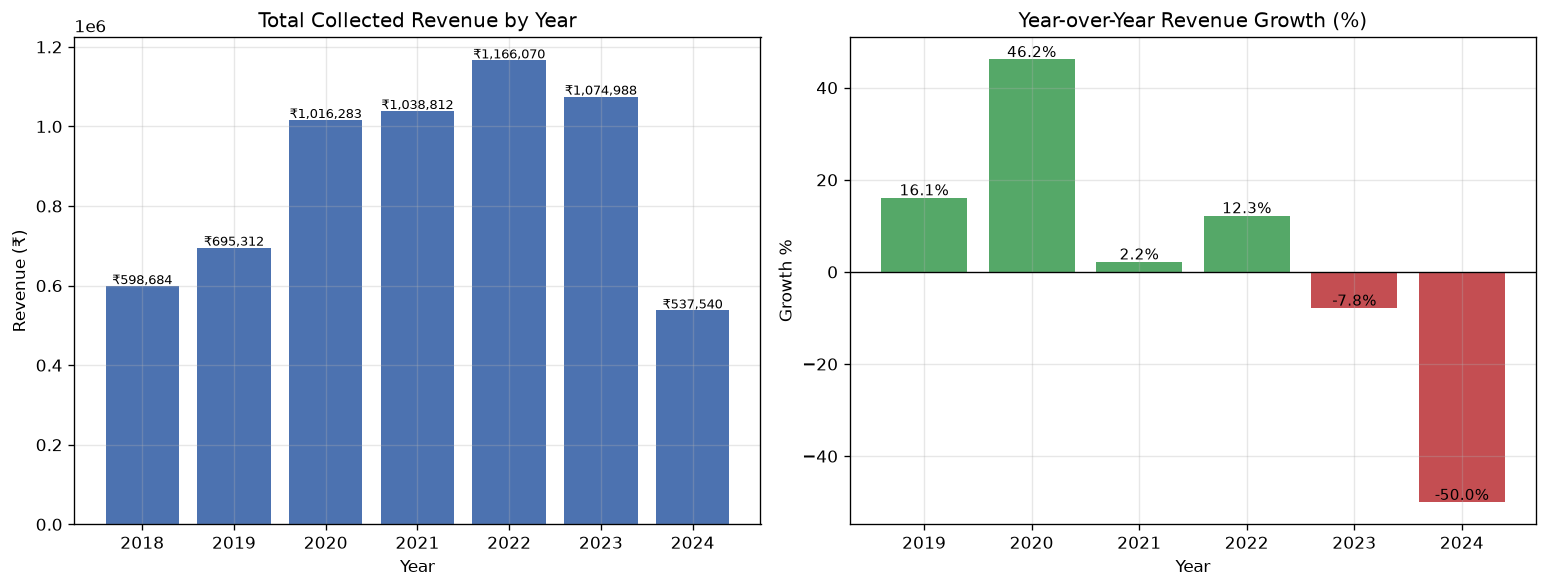

In [10]:
total_yearly = sql_grid("""
    SELECT DATE_PART('year', b.Billing_Date)::int AS year,
           SUM(CASE WHEN b.Payment_Status = 'Paid' THEN b.Total_Price ELSE 0 END) AS revenue
    FROM Bill b
    GROUP BY year
    ORDER BY year;
""")

total_yearly["yoy_growth_pct"] = total_yearly["revenue"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue bars
axes[0].bar(total_yearly["year"], total_yearly["revenue"], color="#4C72B0")
axes[0].set_title("Total Collected Revenue by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Revenue (₹)")
for i, row in total_yearly.iterrows():
    axes[0].text(row["year"], row["revenue"] + 5000, f"₹{row['revenue']:,.0f}", ha="center", fontsize=8)

# YoY growth
growth_data = total_yearly.dropna(subset=["yoy_growth_pct"])
bar_colors = ["#55A868" if g >= 0 else "#C44E52" for g in growth_data["yoy_growth_pct"]]
axes[1].bar(growth_data["year"], growth_data["yoy_growth_pct"], color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Year-over-Year Revenue Growth (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Growth %")
for i, row in growth_data.iterrows():
    axes[1].text(row["year"], row["yoy_growth_pct"] + 0.5, f"{row['yoy_growth_pct']:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 — Revenue by State

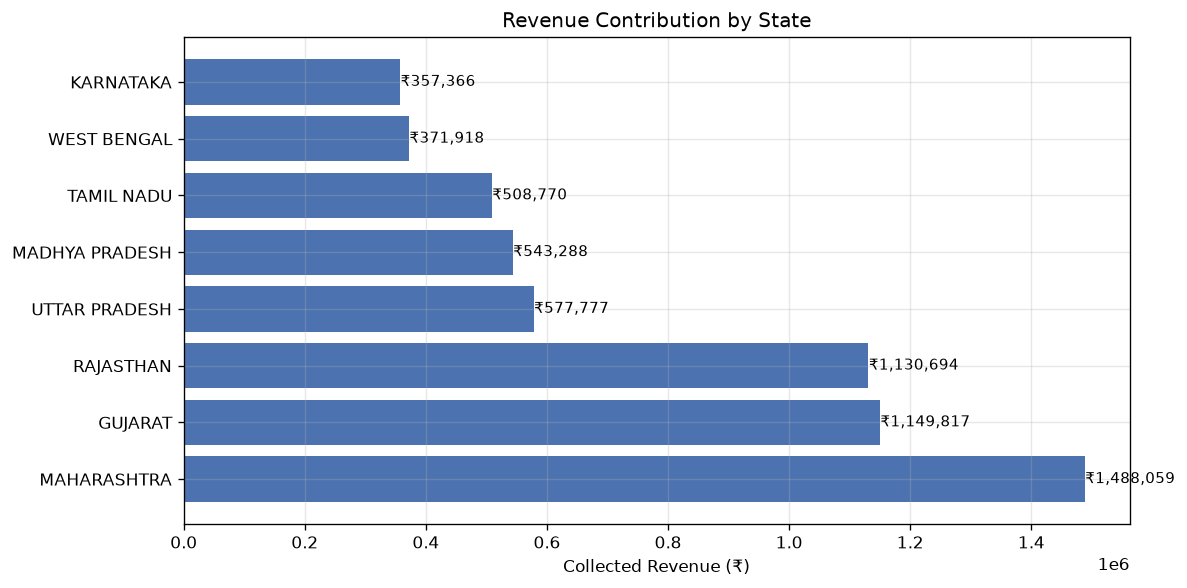

Top state (MAHARASHTRA) contributes 24.3% of total revenue


In [11]:
rev_state = sql_grid("""
    SELECT pc.State,
           SUM(CASE WHEN b.Payment_Status = 'Paid' THEN b.Total_Price ELSE 0 END) AS revenue
    FROM Bill b
    JOIN Meter m              ON b.Meter_ID    = m.Meter_ID
    JOIN Customer c           ON m.Customer_ID = c.Customer_ID
    JOIN Pin_Code pc          ON c.Pin_Code    = pc.Pin_Code
    GROUP BY pc.State
    ORDER BY revenue DESC;
""")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rev_state["state"], rev_state["revenue"], color="#4C72B0")
ax.set_xlabel("Collected Revenue (₹)")
ax.set_title("Revenue Contribution by State")
for i, v in enumerate(rev_state["revenue"]):
    ax.text(v + 1000, i, f"₹{v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Concentration
top_state_share = rev_state["revenue"].iloc[0] / rev_state["revenue"].sum() * 100
print(f"Top state ({rev_state['state'].iloc[0]}) contributes {top_state_share:.1f}% of total revenue")

### 2.5 — Unpaid Bill Exposure

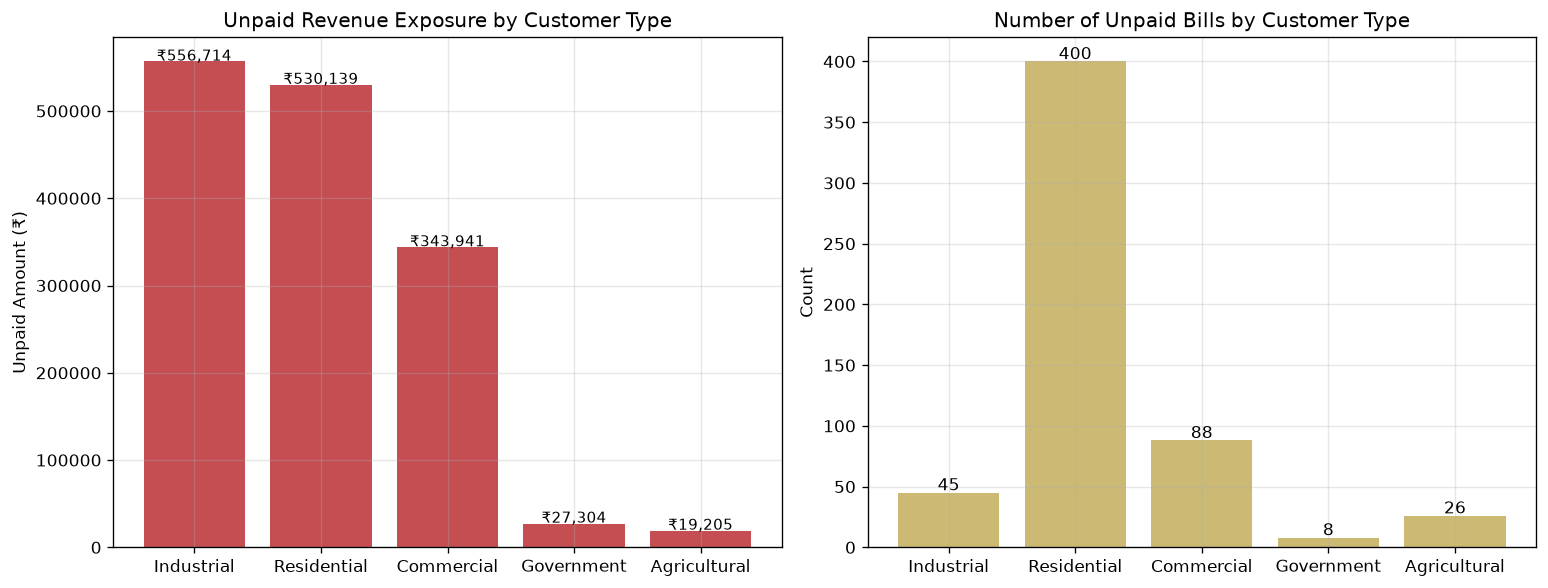

Total unpaid exposure: ₹1,477,302

   type_name  unpaid_count  unpaid_amount  avg_unpaid_bill
  Industrial            45      556713.68         12371.42
 Residential           400      530138.70          1325.35
  Commercial            88      343940.59          3908.42
  Government             8       27303.99          3413.00
Agricultural            26       19205.33           738.67


In [12]:
unpaid = sql_grid("""
    SELECT ct.Type_Name,
           COUNT(*)              AS unpaid_count,
           SUM(b.Total_Price)    AS unpaid_amount,
           AVG(b.Total_Price)    AS avg_unpaid_bill
    FROM Bill b
    JOIN Electricity_Rate er ON er.Rate_ID = b.Rate_ID
    JOIN Customer_Type ct    ON ct.Customer_Type_ID = er.Customer_Type_ID
    WHERE b.Payment_Status = 'Unpaid'
    GROUP BY ct.Type_Name
    ORDER BY unpaid_amount DESC;
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Unpaid amount by type
axes[0].bar(unpaid["type_name"], unpaid["unpaid_amount"], color="#C44E52")
axes[0].set_title("Unpaid Revenue Exposure by Customer Type")
axes[0].set_ylabel("Unpaid Amount (₹)")
for i, v in enumerate(unpaid["unpaid_amount"]):
    axes[0].text(i, v + 1000, f"₹{v:,.0f}", ha="center", fontsize=9)

# Count of unpaid bills
axes[1].bar(unpaid["type_name"], unpaid["unpaid_count"], color="#CCB974")
axes[1].set_title("Number of Unpaid Bills by Customer Type")
axes[1].set_ylabel("Count")
for i, v in enumerate(unpaid["unpaid_count"]):
    axes[1].text(i, v + 2, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

total_unpaid = unpaid["unpaid_amount"].sum()
print(f"Total unpaid exposure: ₹{total_unpaid:,.0f}")
print(f"\n{unpaid[['type_name', 'unpaid_count', 'unpaid_amount', 'avg_unpaid_bill']].round(2).to_string(index=False)}")

## 3 · Hypothesis Testing

**Question:** "Do Industrial customers generate significantly higher bills than Residential customers?"

**Approach:**
1. Pull per-bill amounts for both segments
2. Run a Welch's two-sample t-test (does not assume equal variance)
3. State the conclusion at α = 0.05

**Hypotheses:**
- **H₀:** $μ_{Industrial}$ = $μ_{Residential}$ (no significant difference in mean bill amounts)
- **H₁:** $μ_{Industrial}$ > $μ_{Residential}$ (Industrial bills are significantly higher)

### 3.1 — Pull bill amounts for both customer types

In [13]:
from scipy import stats

bills_by_type = sql_grid("""
    SELECT ct.Type_Name, b.Total_Price
    FROM Bill b
    JOIN Electricity_Rate er ON b.Rate_ID = er.Rate_ID
    JOIN Customer_Type ct    ON er.Customer_Type_ID = ct.Customer_Type_ID
    WHERE ct.Type_Name IN ('Residential', 'Industrial');
""")

residential = bills_by_type[bills_by_type["type_name"] == "Residential"]["total_price"].astype(float)
industrial  = bills_by_type[bills_by_type["type_name"] == "Industrial"]["total_price"].astype(float)

print(f"Residential bills: n = {len(residential)}")
print(f"Industrial  bills: n = {len(industrial)}")

Residential bills: n = 2104
Industrial  bills: n = 240


### 3.2 — Descriptive Comparison

In [14]:
# Side-by-side descriptive stats
desc = pd.DataFrame({
    "Residential": residential.describe(),
    "Industrial":  industrial.describe()
}).round(2)
print(desc)
print(f"\nDifference in means: ₹{industrial.mean() - residential.mean():,.2f}")

       Residential  Industrial
count      2104.00      240.00
mean       1355.21    12688.01
std         663.45     6613.07
min         200.21     2222.67
25%         789.66     6616.45
50%        1356.71    12505.72
75%        1918.62    17842.32
max        2499.77    24953.90

Difference in means: ₹11,332.79


### 3.3 — Welch's Two-Sample t-Test

We'll use **Welch's t-test** (not Student's) because the two groups have different sample sizes and likely different variances.

In [15]:
# One-tailed Welch's t-test: Industrial > Residential
t_stat, p_value_two_tailed = stats.ttest_ind(industrial, residential, equal_var=False)
p_value_one_tailed = p_value_two_tailed / 2  # one-tailed (greater)

alpha = 0.05

print("=" * 50)
print("  Welch's t-Test Results")
print("=" * 50)
print(f"  t-statistic     : {t_stat:.4f}")
print(f"  p-value (2-tail): {p_value_two_tailed:.6f}")
print(f"  p-value (1-tail): {p_value_one_tailed:.6f}")
print(f"  Significance (α): {alpha}")
print("-" * 50)

if p_value_one_tailed < alpha and t_stat > 0:
    print("  ✅ REJECT H₀ — Industrial bills are significantly")
    print("     higher than Residential bills.")
else:
    print("  ❌ FAIL TO REJECT H₀ — No significant difference.")
print("=" * 50)

  Welch's t-Test Results
  t-statistic     : 26.5333
  p-value (2-tail): 0.000000
  p-value (1-tail): 0.000000
  Significance (α): 0.05
--------------------------------------------------
  ✅ REJECT H₀ — Industrial bills are significantly
     higher than Residential bills.


## 4 · Executive Summary Dashboard
 Here We compute 6 KPIs, assign a RAG (Red / Amber / Green) status to each, and present them as a table alongside a visual summary.

### 4.1 — Compute KPIs

In [16]:
# KPI 1: Total Collected Revenue
kpi_revenue = sql_grid("""
    SELECT SUM(Total_Price) AS val FROM Bill WHERE Payment_Status = 'Paid';
""")["val"].iloc[0]

# KPI 2: Collection Rate
kpi_gross = sql_grid("SELECT SUM(Total_Price) AS val FROM Bill;")["val"].iloc[0]
kpi_collection_rate = float(kpi_revenue / kpi_gross * 100)

# KPI 3: Customer Growth (latest year vs first year meter installs)
kpi_growth = sql_grid("""
    SELECT
        COUNT(DISTINCT CASE WHEN DATE_PART('year', Installation_Date) <= 2018 THEN Customer_ID END) AS early,
        COUNT(DISTINCT CASE WHEN DATE_PART('year', Installation_Date) >= 2021 THEN Customer_ID END) AS recent
    FROM Meter;
""")
early = max(int(kpi_growth["early"].iloc[0]), 1)
recent = int(kpi_growth["recent"].iloc[0])
kpi_cust_growth = (recent - early) / early * 100

# KPI 4: Avg Outage Duration (hours) — Mean Time to Resolve
kpi_mttr = sql_grid("""
    SELECT AVG(EXTRACT(EPOCH FROM (End_Date_Time - Start_Date_Time)) / 3600) AS val
    FROM Outage
    WHERE Status = 'Resolved';
""")["val"].iloc[0]
kpi_mttr = round(float(kpi_mttr), 1)

# KPI 5: Feeder Overload Rate
kpi_total_feeders = sql_grid("SELECT COUNT(*) AS val FROM Feeder;")["val"].iloc[0]
kpi_overloaded_feeders = sql_grid("""
    SELECT COUNT(*) AS val FROM (
        SELECT f.Feeder_ID
        FROM Feeder f
        LEFT JOIN Meter m ON f.Feeder_ID = m.Feeder_ID
        GROUP BY f.Feeder_ID, f.Load_Profile
        HAVING COUNT(m.Meter_ID) > (0.9 * 1000 * f.Load_Profile) / 1.5
    ) sub;
""")["val"].iloc[0]
kpi_overload_rate = float(kpi_overloaded_feeders / kpi_total_feeders * 100)

# KPI 6: Avg Substation Utilisation
kpi_avg_util = sql_grid("""
    SELECT AVG(util) AS val FROM (
        SELECT COALESCE(SUM(f.Capacity), 0) / s.Transformer_Capacity * 100 AS util
        FROM Substation s
        LEFT JOIN Feeder f ON s.Substation_ID = f.Substation_ID
        GROUP BY s.Substation_ID, s.Transformer_Capacity
    ) sub;
""")["val"].iloc[0]
kpi_avg_util = round(float(kpi_avg_util), 1)

print("KPIs computed ✓")

KPIs computed ✓


### 4.2 — RAG Status

In [17]:
# Define KPIs with thresholds
kpis = [
    {
        "kpi": "Total Collected Revenue",
        "value": f"₹{kpi_revenue:,.0f}",
        "raw": float(kpi_revenue),
        "threshold_green": 1_500_000,
        "threshold_amber": 1_000_000,
        "higher_is_better": True,
    },
    {
        "kpi": "Collection Rate",
        "value": f"{kpi_collection_rate:.1f}%",
        "raw": kpi_collection_rate,
        "threshold_green": 85,
        "threshold_amber": 75,
        "higher_is_better": True,
    },
    {
        "kpi": "Customer Growth (early→recent)",
        "value": f"{kpi_cust_growth:+.1f}%",
        "raw": kpi_cust_growth,
        "threshold_green": 20,
        "threshold_amber": 0,
        "higher_is_better": True,
    },
    {
        "kpi": "Outage MTTR (hours)",
        "value": f"{kpi_mttr} hrs",
        "raw": kpi_mttr,
        "threshold_green": 20,
        "threshold_amber": 30,
        "higher_is_better": False,
    },
    {
        "kpi": "Feeder Overload Rate",
        "value": f"{kpi_overload_rate:.1f}%",
        "raw": kpi_overload_rate,
        "threshold_green": 10,
        "threshold_amber": 25,
        "higher_is_better": False,
    },
    {
        "kpi": "Avg Substation Utilisation",
        "value": f"{kpi_avg_util}%",
        "raw": kpi_avg_util,
        "threshold_green": 60,
        "threshold_amber": 80,
        "higher_is_better": False,
    },
]

def assign_rag(k):
    v = k["raw"]
    g, a = k["threshold_green"], k["threshold_amber"]
    if k["higher_is_better"]:
        if v >= g: return "🟢 GREEN"
        elif v >= a: return "🟡 AMBER"
        else: return "🔴 RED"
    else:
        if v <= g: return "🟢 GREEN"
        elif v <= a: return "🟡 AMBER"
        else: return "🔴 RED"

for k in kpis:
    k["status"] = assign_rag(k)

dashboard = pd.DataFrame([{"KPI": k["kpi"], "Value": k["value"], "Status": k["status"]} for k in kpis])
print(dashboard.to_string(index=False))

                           KPI      Value  Status
       Total Collected Revenue ₹6,127,689 🟢 GREEN
               Collection Rate      80.6% 🟡 AMBER
Customer Growth (early→recent)     -56.1%   🔴 RED
           Outage MTTR (hours)   26.6 hrs 🟡 AMBER
          Feeder Overload Rate       7.9% 🟢 GREEN
    Avg Substation Utilisation      29.5% 🟢 GREEN
